## 모델용 CSV 저장

In [ ]:
import pandas as pd
from pathlib import Path

BASE_DIR = Path(r"C:\dev\SKN18-FINAL-1TEAM\apps\reco\models\price_model\data")


# -------------------------------
# 1) 월세 데이터 전처리 함수
# -------------------------------
def load_and_filter_monthly(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, encoding="cp949")

    # 전월세 구분/면적 컬럼 자동 감지
    col_rent = "전월세구분" if "전월세구분" in df.columns else "전월세 구분"
    col_area = "임대면적" if "임대면적" in df.columns else "임대면적(㎡)"

    # 월세만 사용
    df = df[df[col_rent].astype(str).str.contains("월세", na=False)]

    # 층 처리
    df["층"] = pd.to_numeric(df.get("층", 0), errors="coerce").fillna(0)

    # 건축년도 null 제거
    df = df.dropna(subset=["건축년도"])

    # 계약일 처리 + 기간 필터링
    df["계약일"] = pd.to_datetime(df["계약일"].astype(str), format="%Y%m%d", errors="coerce")
    df = df[(df["계약일"] >= "2024-08-01") & (df["계약일"] <= "2025-10-31")]

    # 필요한 컬럼만 선택 + 통일
    df = df[[
        "자치구명", "법정동명", "층", "계약일",
        col_rent, col_area,
        "보증금(만원)", "임대료(만원)",
        "건축년도", "건물용도"
    ]].rename(columns={col_rent: "전월세구분", col_area: "임대면적"})

    return df


# -------------------------------
# 2) 금리 데이터 로드 함수
# -------------------------------
def load_rate_table(path: Path, id_col: str) -> pd.DataFrame:
    rate = pd.read_csv(path, encoding="utf-8-sig")
    rate.columns = [c.strip() for c in rate.columns]

    # month 컬럼 "2024.08" → "2024-08"
    rename_map = {
        c: f"{c.split('.')[0]}-{c.split('.')[1].zfill(2)}"
        for c in rate.columns if c != id_col
    }
    rate = rate.rename(columns=rename_map)

    # wide → long → wide
    rate_long = rate.melt(id_vars=id_col, var_name="연월", value_name="값")
    rate_pivot = rate_long.pivot(index="연월", columns=id_col, values="값").reset_index()


    # 실제 CSV의 '구분' 값에 맞춰 이름 매핑
    rate_pivot = rate_pivot.rename(columns={
        "소비자물가": "소비자물가",
        "무담보콜금리(1일)": "무담보콜금리",
        "KORIBOR(3개월)": "KORIBOR",
        "CD(91일)": "CD",
        "기업대출": "기업대출",
        "전세자금대출": "전세자금대출",
        "변동형 주택담보대출": "변동형주택담보대출",
    })

    # 숫자 변환
    for col in rate_pivot.columns:
        if col != "연월":
            rate_pivot[col] = pd.to_numeric(rate_pivot[col], errors="coerce")

    return rate_pivot


# -------------------------------
# 3) 한국은행 기준금리 로드 함수
# -------------------------------
def load_base_rate(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, encoding="utf-8-sig")
    df.columns = [c.strip() for c in df.columns]

    id_col = "계정항목"
    rename_map = {
        c: f"{c.split('.')[0]}-{c.split('.')[1].zfill(2)}"
        for c in df.columns if c != id_col
    }
    df = df.rename(columns=rename_map)

    # melt
    long_df = df.melt(id_vars=id_col, var_name="연월", value_name="값")
    base = long_df[long_df[id_col] == "한국은행 기준금리"][["연월", "값"]]
    base = base.rename(columns={"값": "기준금리"})
    base["기준금리"] = pd.to_numeric(base["기준금리"], errors="coerce")
    return base


# -------------------------------
# 4) 실행 파트
# -------------------------------
if __name__ == "__main__":

    # 월세 데이터 합치기
    df_2024 = load_and_filter_monthly(BASE_DIR / "서울특별시_전월세가_2024.csv")
    df_2025 = load_and_filter_monthly(BASE_DIR / "서울특별시_전월세가_2025.csv")

    df = pd.concat([df_2024, df_2025], ignore_index=True)

    # 연월만 사용
    df["연월"] = df["계약일"].dt.to_period("M").astype(str)
    df = df.drop(columns=["계약일"])

    # 숫자형 통일
    for col in ["층", "임대면적", "보증금(만원)", "임대료(만원)", "건축년도"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # -------------------------------
    # 금리 테이블 병합
    # -------------------------------
    rate1 = load_rate_table(BASE_DIR / "(총합)시장금리_및_대출금리(24.8~25.10).csv", "구분")
    base_rate = load_base_rate(BASE_DIR / "한국은행_기준금리(24.08~25.10).csv")

    # 금리 전체 테이블
    rate_all = rate1.merge(base_rate, on="연월", how="left")

    # 월세 데이터와 merge
    df = df.merge(rate_all, on="연월", how="left")

    # -------------------------------
    # 모델링용 컬럼만 유지
    # -------------------------------
    model_cols = [
        "자치구명", "법정동명", "층", "연월",
        "임대면적", "보증금(만원)", "임대료(만원)",
        "건축년도", "건물용도",
        "소비자물가", "무담보콜금리", "KORIBOR", "CD",
        "기업대출", "전세자금대출",
        "변동형주택담보대출", "기준금리"
    ]

    df_model = df[model_cols].copy()

    # 저장
    out = BASE_DIR / "월세_모델링용(24.08~25.10)_(1).csv"
    df_model.to_csv(out, index=False, encoding="utf-8-sig")
    print("저장 완료:", out)

    # -------------------------------
    # Train/Test Split
    # -------------------------------
    # Train: 2024-01 ~ 2025-08
    train_months = [f"2024-{m:02d}" for m in range(1, 13)] + \
                   [f"2025-{m:02d}" for m in range(1, 9)]

    # Test: 2025-09 ~ 2025-10
    test_months = ["2025-09", "2025-10"]

    df_train = df_model[df_model["연월"].isin(train_months)].copy()
    df_test = df_model[df_model["연월"].isin(test_months)].copy()

    # 저장
    out_train = BASE_DIR / "월세_train(24.01~25.08).csv"
    out_test = BASE_DIR / "월세_test(25.09~25.10).csv"

    df_train.to_csv(out_train, index=False, encoding="utf-8-sig")
    df_test.to_csv(out_test, index=False, encoding="utf-8-sig")

    print("Train 저장 완료:", out_train)
    print("Test 저장 완료:", out_test)

모델링용 전처리 데이터 저장 완료: C:\dev\SKN18-FINAL-1TEAM\apps\reco\models\price_model\data\월세_모델링용(24.08~25.10).csv
완료


## 확인용

In [ ]:
import pandas as pd

path_2024 = r"C:\dev\SKN18-FINAL-1TEAM\apps\reco\models\price_model\data\서울특별시_전월세가_2024.csv"
path_2025 = r"C:\dev\SKN18-FINAL-1TEAM\apps\reco\models\price_model\data\서울특별시_전월세가_2025.csv"

df24 = pd.read_csv(path_2024, encoding="cp949")
df25 = pd.read_csv(path_2025, encoding="cp949")

print("=== 2024 ===")
print(df24.shape)          # (행 수, 컬럼 수)
print(df24.columns)        # 컬럼 이름
df24.head(3)               # 앞 3행

# print("\n=== 2025 ===")
# print(df25.shape)
# print(df25.columns)
# print(df25.head(3))


In [ ]:
import pandas as pd

path_all = r"C:\dev\SKN18-FINAL-1TEAM\apps\reco\models\price_model\data\월세_전처리(24.08~25.11).csv"
all = pd.read_csv(path_all, encoding="utf-8")

total_rows = len(all)

missing_df = pd.DataFrame({
    "결측치수": all.isna().sum(),
    "결측치비율(%)": all.isna().mean() * 100
})

print(missing_df)
print("전체 행 수 :", total_rows)


         결측치수  결측치비율(%)
자치구명        0       0.0
법정동명        0       0.0
층           0       0.0
계약일         0       0.0
전월세구분       0       0.0
임대면적        0       0.0
보증금(만원)     0       0.0
임대료(만원)     0       0.0
건축년도        0       0.0
건물용도        0       0.0


In [ ]:
# 계약일을 datetime으로 확실하게 변환
df["계약일"] = pd.to_datetime(df["계약일"], errors="coerce")
print(df["계약일"])

0        2024-12-06
1        2024-10-30
2        2024-10-30
3        2024-09-30
4        2024-08-29
            ...    
734420   2024-08-01
734421   2024-08-01
734422   2024-08-01
734423   2024-08-01
734424   2024-08-01
Name: 계약일, Length: 734425, dtype: datetime64[ns]


In [ ]:
# 계약연월(YYYY-MM) 생성 → 금리 join 키
df["연월"] = df["계약일"].dt.strftime("%Y-%m")
print(df["연월"])

0         2024-12
1         2024-10
2         2024-10
3         2024-09
4         2024-08
           ...   
734420    2024-08
734421    2024-08
734422    2024-08
734423    2024-08
734424    2024-08
Name: 연월, Length: 734425, dtype: object


In [ ]:
# 숫자 컬럼 정리
num_cols = ["층", "임대면적", "보증금(만원)", "임대료(만원)", "건축년도"]
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

print(df[c])

0         1998.0
1         2024.0
2         2018.0
3         1996.0
4            NaN
           ...  
734420    2001.0
734421    1982.0
734422    1986.0
734423    2012.0
734424       NaN
Name: 건축년도, Length: 734425, dtype: float64


In [46]:
# -------------------------------
# 2) 금리 CSV 1: '구분' 기준 (시장금리/전세자금대출/주담대 등)
# -------------------------------
rate_market_path = BASE_DIR / "(총합)시장금리_및_대출금리(24.8~25.10).csv" 

rate1 = pd.read_csv(rate_market_path, encoding="utf-8")
rate1.columns = [c.strip() for c in rate1.columns]

id_col = "구분"
month_cols = [c for c in rate1.columns if c != id_col]

# "2024.08" → "2024-08"
rename_month = {}
for c in month_cols:
    year, month = c.split(".")
    rename_month[c] = f"{year}-{month.zfill(2)}"

rate1 = rate1.rename(columns=rename_month)

rate1_long = rate1.melt(
        id_vars=id_col,
        var_name="연월",
        value_name="값"
)

rate1_pivot = rate1_long.pivot(
        index="연월",
        columns=id_col,
        values="값"
).reset_index()

rate1_pivot = rate1_pivot.rename(columns={
        "소비자물가": "소비자물가",
        "무담보콜금리(1일)": "무담보콜금리",
        "KORIBOR(3개월)": "KORIBOR",
        "CD(91일)": "CD",
        "기업대출": "기업대출",
        "전세자금대출": "전세자금대출",
        "변동형 주택담보대출": "변동형주택담보대출",
})

# 숫자로 캐스팅
for col in rate1_pivot.columns:
    if col != "연월":
        rate1_pivot[col] = pd.to_numeric(rate1_pivot[col], errors="coerce")

# ============================
# 중간 결과 출력해서 확인
# ============================
print("=== 원본 rate1 (상위 5행) ===")
print(rate1.head(), "\n")

print("=== Long 형태 rate1_long (상위 5행) ===")
print(rate1_long.head(), "\n")

print("=== 피벗된 rate1_pivot (상위 5행) ===")
print(rate1_pivot.head(), "\n")

print("=== rate1_pivot dtypes ===")
print(rate1_pivot.dtypes)



=== 원본 rate1 (상위 5행) ===
             구분  2024-08  2024-09  2024-10  2024-11  2024-12  2025-01  \
0         소비자물가    2.000    1.600    1.300    1.500    1.900    2.200   
1    무담보콜금리(1일)    3.531    3.529    3.321    3.245    3.055    3.053   
2  KORIBOR(3개월)    3.450    3.490    3.430    3.400    3.310    3.120   
3       CD(91일)    3.500    3.520    3.430    3.420    3.350    3.040   
4          기업대출    4.670    4.770    4.710    4.760    4.620    4.500   

   2025-02  2025-03  2025-04  2025-05  2025-06  2025-07  2025-08  2025-09  \
0    2.000    2.100    2.100    1.900     2.20     2.10    1.700    2.100   
1    2.965    2.754    2.769    2.738     2.52     2.50    2.506    2.526   
2    2.980    2.870    2.760    2.660     2.57     2.52    2.500    2.510   
3    2.950    2.840    2.740    2.670     2.57     2.51    2.510    2.560   
4    4.430    4.320    4.140    4.160     4.06     4.04    4.030    3.990   

   2025-10  
0    2.400  
1    2.516  
2    2.540  
3    2.550  
4    3.9

In [47]:
# -------------------------------
# 3) 금리 CSV 2: 한국은행 기준금리
# -------------------------------
rate_base_path = BASE_DIR / "한국은행_기준금리(24.08~25.10).csv"  # 예시 이름

rate2 = pd.read_csv(rate_base_path, encoding="utf-8-sig")
rate2.columns = [c.strip() for c in rate2.columns]

id_col2 = "계정항목"
month_cols2 = [c for c in rate2.columns if c != id_col2]

rename_month2 = {}
for c in month_cols2:
    year, month = c.split(".")
    rename_month2[c] = f"{year}-{month.zfill(2)}"

rate2 = rate2.rename(columns=rename_month2)

rate2_long = rate2.melt(
        id_vars=id_col2,
        var_name="연월",
        value_name="값"
)

base_rate = rate2_long[rate2_long[id_col2] == "한국은행 기준금리"].copy()
base_rate = base_rate[["연월", "값"]].rename(columns={"값": "기준금리"})

# 숫자 변환
base_rate["기준금리"] = pd.to_numeric(base_rate["기준금리"], errors="coerce")

print("=== rate2 (원본, 상위 5행) ===")
print(rate2.head(), "\n")

print("=== rate2_long (Long 형태, 상위 5행) ===")
print(rate2_long.head(), "\n")

print("=== base_rate (기준금리만, 상위 5행) ===")
print(base_rate.head(), "\n")

print("=== base_rate dtypes ===")
print(base_rate.dtypes)

=== rate2 (원본, 상위 5행) ===
        계정항목  2024-08  2024-09  2024-10  2024-11  2024-12  2025-01  2025-02  \
0  한국은행 기준금리      3.5      3.5      3.5     3.25      3.0      3.0      3.0   

   2025-03  2025-04  2025-05  2025-06  2025-07  2025-08  2025-09  2025-10  
0     2.75     2.75     2.75      2.5      2.5      2.5      2.5      2.5   

=== rate2_long (Long 형태, 상위 5행) ===
        계정항목       연월     값
0  한국은행 기준금리  2024-08  3.50
1  한국은행 기준금리  2024-09  3.50
2  한국은행 기준금리  2024-10  3.50
3  한국은행 기준금리  2024-11  3.25
4  한국은행 기준금리  2024-12  3.00 

=== base_rate (기준금리만, 상위 5행) ===
        연월  기준금리
0  2024-08  3.50
1  2024-09  3.50
2  2024-10  3.50
3  2024-11  3.25
4  2024-12  3.00 

=== base_rate dtypes ===
연월       object
기준금리    float64
dtype: object


In [ ]:
# -------------------------------
# 4) 시장금리 + 기준금리 통합
# -------------------------------
rate_all = rate1_pivot.merge(base_rate, on="연월", how="left")

print("=== rate_all ===")
print(rate_all.shape)
print(rate_all.head())
print(rate_all.dtypes, "\n")

# 1) df_all에 연월 생성 (이미 했다면 생략)
df["계약일"] = pd.to_datetime(df["계약일"], format="%Y%m%d")
df["연월"] = df["계약일"].dt.strftime("%Y-%m")

print("=== df_all 연월 생성 후 ===")
print(df[["계약일", "연월"]].head(), "\n")

# 2) 금리 머지
df_all = df.merge(rate_all, on="연월", how="left")

print("=== df_all (금리 포함) ===")
print(df_all.shape)
print(df_all.head())
print(df_all.dtypes, "\n")

# 3) 금리가 잘 붙었는지 추가 체크 (선택)
print("=== 기준금리 null 개수 ===")
print(df_all["기준금리"].isna().sum())


=== rate_all ===
(15, 9)
        연월    CD  KORIBOR  기업대출  무담보콜금리  변동형주택담보대출  소비자물가  전세자금대출  기준금리
0  2024-08  3.50     3.45  4.67   3.531       4.04    2.0    3.82  3.50
1  2024-09  3.52     3.49  4.77   3.529       4.08    1.6    4.05  3.50
2  2024-10  3.43     3.43  4.71   3.321       4.14    1.3    4.26  3.50
3  2024-11  3.42     3.40  4.76   3.245       4.25    1.5    4.43  3.25
4  2024-12  3.35     3.31  4.62   3.055       4.32    1.9    4.34  3.00
연월            object
CD           float64
KORIBOR      float64
기업대출         float64
무담보콜금리       float64
변동형주택담보대출    float64
소비자물가        float64
전세자금대출       float64
기준금리         float64
dtype: object 

=== df_all 연월 생성 후 ===
         계약일       연월
0 2024-12-06  2024-12
1 2024-10-30  2024-10
2 2024-10-30  2024-10
3 2024-09-30  2024-09
4 2024-11-15  2024-11 

=== df_all (금리 포함) ===
(693167, 19)
  자치구명  법정동명    층        계약일 전월세구분   임대면적  보증금(만원)  임대료(만원)    건축년도   건물용도  \
0  마포구  노고산동  5.0 2024-12-06    월세  31.12     8000       50  1998.0

In [ ]:
#--------------------------
# train/test 날짜별 비율
#--------------------------

import pandas as pd
from pathlib import Path

BASE_DIR = Path(r"C:\dev\SKN18-FINAL-1TEAM\apps\reco\models\price_model\data")
csv_path = BASE_DIR / "월세_모델링용(24.08~25.10).csv"

# CSV 로드
df = pd.read_csv(csv_path, encoding="utf-8-sig")

# 연월 정렬
df["연월"] = df["연월"].astype(str)
df = df.sort_values("연월")

# Train/Test 구간 정의
train_months = [f"2024-{m:02d}" for m in range(1, 13)] + \
               [f"2025-{m:02d}" for m in range(1, 9)]

test_months  = ["2025-09", "2025-10"]

# Train/Test 라벨 추가
df["set"] = df["연월"].apply(
    lambda x: "train" if x in train_months else ("test" if x in test_months else "other")
)

# 월별 개수 집계
monthly_counts = df.groupby(["연월", "set"]).size().reset_index(name="rows")

# 전체 대비 비율 추가
total_rows = len(df)
monthly_counts["ratio(%)"] = (monthly_counts["rows"] / total_rows * 100).round(2)

print(monthly_counts)


         연월    set   rows  ratio(%)
0   2024-08  train  24728      3.57
1   2024-09  train  20758      2.99
2   2024-10  train  25547      3.69
3   2024-11  train  28395      4.10
4   2024-12  train  42036      6.06
5   2025-01  train  56962      8.22
6   2025-02  train  69745     10.06
7   2025-03  train  57757      8.33
8   2025-04  train  55247      7.97
9   2025-05  train  58948      8.50
10  2025-06  train  59621      8.60
11  2025-07  train  59691      8.61
12  2025-08  train  59115      8.53
13  2025-09   test  49562      7.15
14  2025-10   test  25055      3.61


# 데이터 분석용

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set(style="whitegrid", font="Malgun Gothic")  # 윈도우 한글 폰트
plt.rcParams["axes.unicode_minus"] = False

DATA_PATH = Path(r"C:\dev\SKN18-FINAL-1TEAM\apps\reco\models\price_model\data\월세_train(24.01~25.08).csv")

df = pd.read_csv(DATA_PATH, encoding="utf-8")  # 필요시 utf-8-sig
print(df.shape)
df.head()

(618550, 17)


,자치구명,법정동명,층,연월,임대면적,보증금(만원),임대료(만원),건축년도,건물용도,소비자물가,무담보콜금리,KORIBOR,CD,기업대출,전세자금대출,변동형주택담보대출,기준금리
0,마포구,노고산동,5.0,2024-12,31.12,8000,50,1998.0,오피스텔,1.9,3.055,3.31,3.35,4.62,4.34,4.32,3.00
1,관악구,신림동,0.0,2024-10,50.00,27000,15,2024.0,단독다가구,1.3,3.321,3.43,3.43,4.71,4.26,4.14,3.50
2,중랑구,면목동,0.0,2024-10,50.00,3000,90,2018.0,단독다가구,1.3,3.321,3.43,3.43,4.71,4.26,4.14,3.50
3,종로구,명륜3가,2.0,2024-09,20.96,500,76,1996.0,연립다세대,1.6,3.529,3.49,3.52,4.77,4.05,4.08,3.50
4,강서구,공항동,0.0,2024-11,46.98,1000,60,2002.0,단독다가구,1.5,3.245,3.40,3.42,4.76,4.43,4.25,3.25


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 618550 entries, 0 to 618549
Data columns (total 17 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   자치구명       618550 non-null  object 
 1   법정동명       618550 non-null  object 
 2   층          618550 non-null  float64
 3   연월         618550 non-null  object 
 4   임대면적       618550 non-null  float64
 5   보증금(만원)    618550 non-null  int64  
 6   임대료(만원)    618550 non-null  int64  
 7   건축년도       618550 non-null  float64
 8   건물용도       618550 non-null  object 
 9   소비자물가      618550 non-null  float64
 10  무담보콜금리     618550 non-null  float64
 11  KORIBOR    618550 non-null  float64
 12  CD         618550 non-null  float64
 13  기업대출       618550 non-null  float64
 14  전세자금대출     618550 non-null  float64
 15  변동형주택담보대출  618550 non-null  float64
 16  기준금리       618550 non-null  float64
dtypes: float64(11), int64(2), object(4)
memory usage: 80.2+ MB


In [6]:
# 결측 비율
(df.isna().mean() * 100).sort_values(ascending=False)

자치구명         0.0
법정동명         0.0
층            0.0
연월           0.0
임대면적         0.0
보증금(만원)      0.0
임대료(만원)      0.0
건축년도         0.0
건물용도         0.0
소비자물가        0.0
무담보콜금리       0.0
KORIBOR      0.0
CD           0.0
기업대출         0.0
전세자금대출       0.0
변동형주택담보대출    0.0
기준금리         0.0
dtype: float64

In [7]:
# 숫자형 변수 기초 통계
df.describe().T

,count,mean,std,min,25%,50%,75%,max
층,618550.0,5.153693,5.981145,-4.00,0.00,3.000,8.000,64.000
임대면적,618550.0,42.039005,29.638507,5.85,21.02,32.800,54.180,445.120
보증금(만원),618550.0,9816.201618,17177.971604,0.00,1000.00,3000.000,12000.000,810000.000
임대료(만원),618550.0,73.291263,82.118590,0.00,35.00,55.000,82.000,9600.000
건축년도,618550.0,2006.301534,13.170679,1006.00,1996.00,2009.000,2018.000,2025.000
소비자물가,618550.0,1.955330,0.235909,1.30,1.90,2.000,2.100,2.200
무담보콜금리,618550.0,2.857858,0.307712,2.50,2.52,2.769,3.053,3.531
KORIBOR,618550.0,2.898889,0.332418,2.50,2.57,2.870,3.120,3.490
CD,618550.0,2.891137,0.338307,2.51,2.57,2.840,3.040,3.520
기업대출,618550.0,4.323645,0.254492,4.03,4.06,4.320,4.500,4.770


In [8]:
# 계약일 → datetime, 연/월/연월
if "계약일" in df.columns:
    df["계약일"] = pd.to_datetime(df["계약일"].astype(str), format="%Y%m%d", errors="coerce")
    df["계약연도"] = df["계약일"].dt.year
    df["계약월"] = df["계약일"].dt.month
    df["연월"] = df["계약일"].dt.to_period("M").astype(str)

# 층/면적/보증금/월세 숫자 변환
for col in ["층", "임대면적", "보증금(만원)", "임대료(만원)", "건축년도"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# 건물 연식
if {"건축년도", "계약연도"}.issubset(df.columns):
    df["건물연식"] = df["계약연도"] - df["건축년도"]

df.head()


,자치구명,법정동명,층,연월,임대면적,보증금(만원),임대료(만원),건축년도,건물용도,소비자물가,무담보콜금리,KORIBOR,CD,기업대출,전세자금대출,변동형주택담보대출,기준금리
0,마포구,노고산동,5.0,2024-12,31.12,8000,50,1998.0,오피스텔,1.9,3.055,3.31,3.35,4.62,4.34,4.32,3.00
1,관악구,신림동,0.0,2024-10,50.00,27000,15,2024.0,단독다가구,1.3,3.321,3.43,3.43,4.71,4.26,4.14,3.50
2,중랑구,면목동,0.0,2024-10,50.00,3000,90,2018.0,단독다가구,1.3,3.321,3.43,3.43,4.71,4.26,4.14,3.50
3,종로구,명륜3가,2.0,2024-09,20.96,500,76,1996.0,연립다세대,1.6,3.529,3.49,3.52,4.77,4.05,4.08,3.50
4,강서구,공항동,0.0,2024-11,46.98,1000,60,2002.0,단독다가구,1.5,3.245,3.40,3.42,4.76,4.43,4.25,3.25


In [9]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols

['층',
 '임대면적',
 '보증금(만원)',
 '임대료(만원)',
 '건축년도',
 '소비자물가',
 '무담보콜금리',
 'KORIBOR',
 'CD',
 '기업대출',
 '전세자금대출',
 '변동형주택담보대출',
 '기준금리']

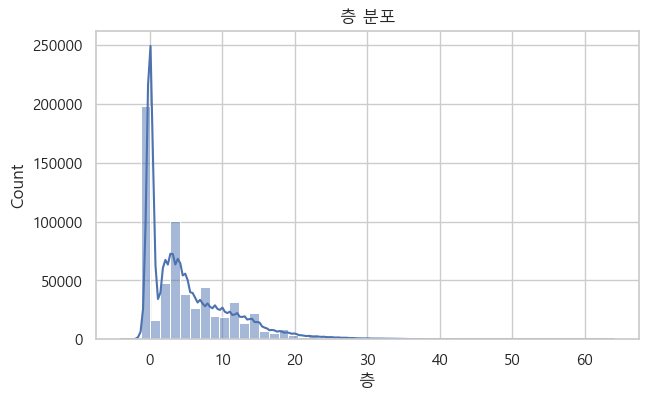

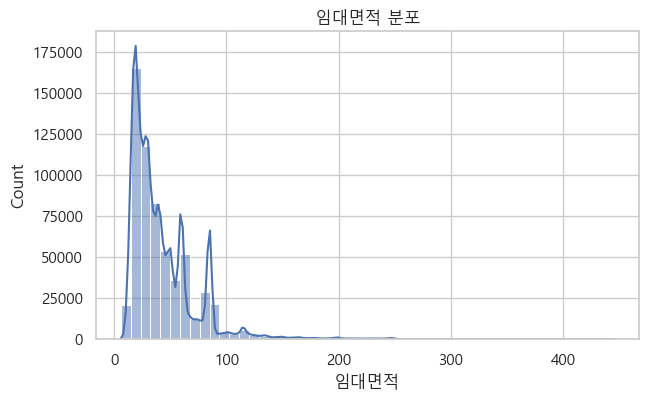

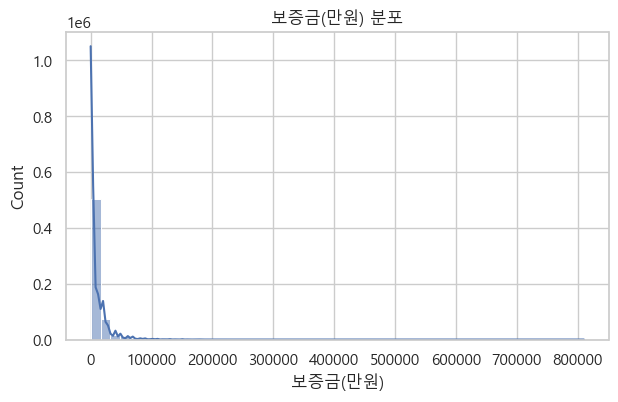

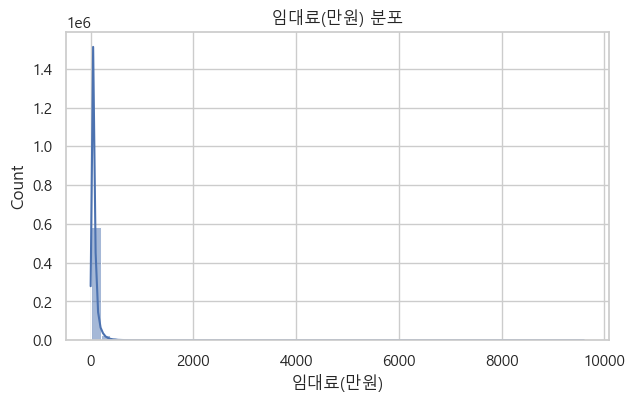

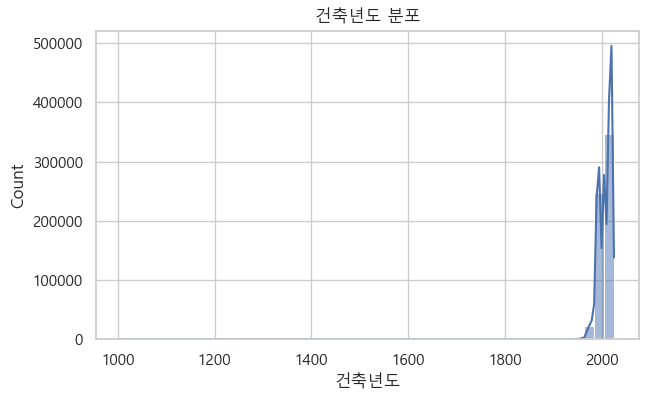

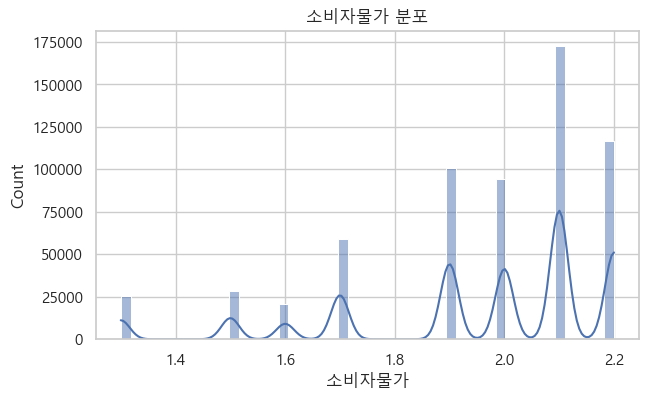

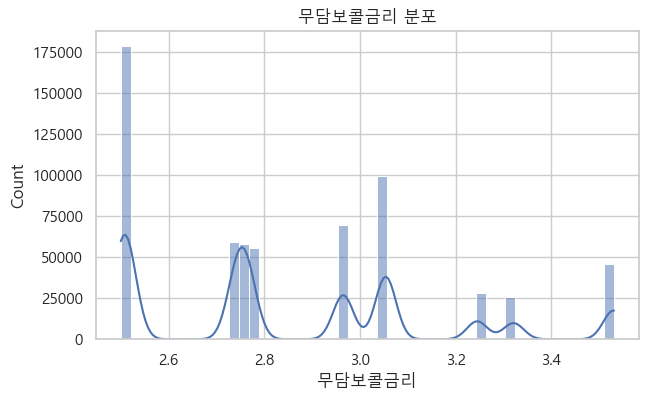

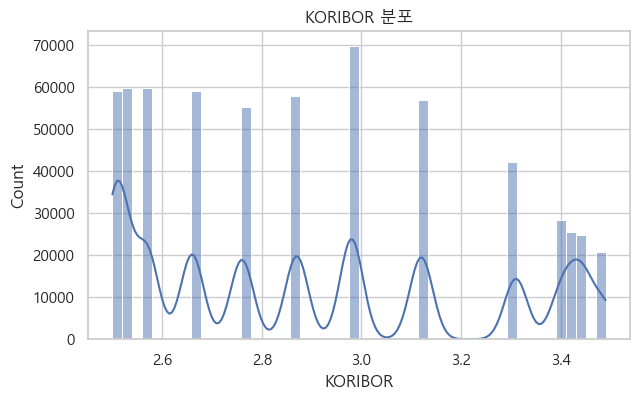

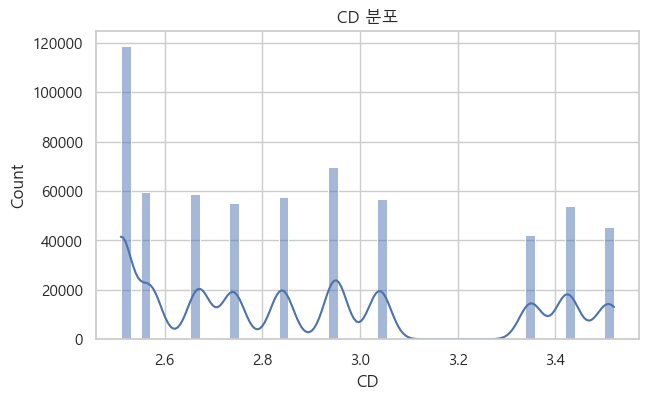

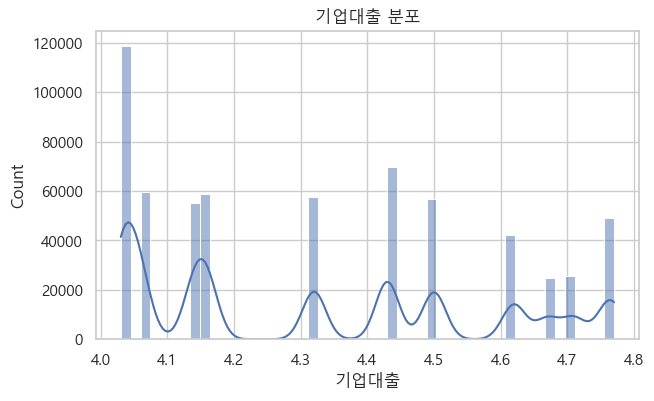

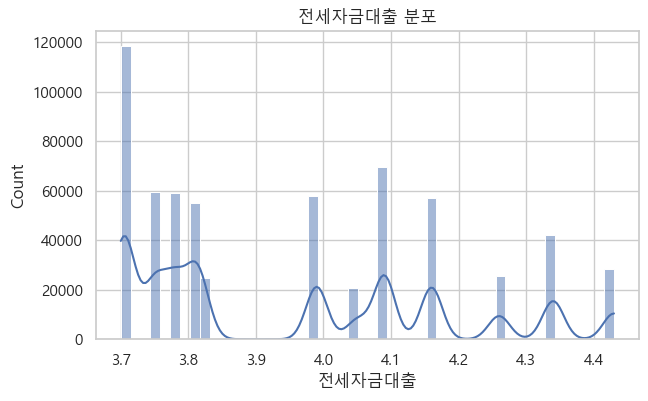

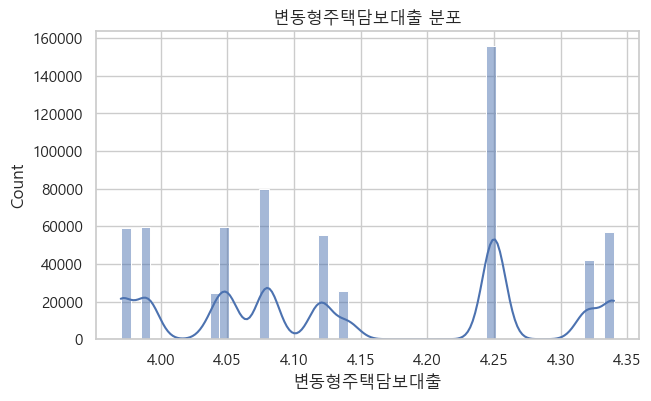

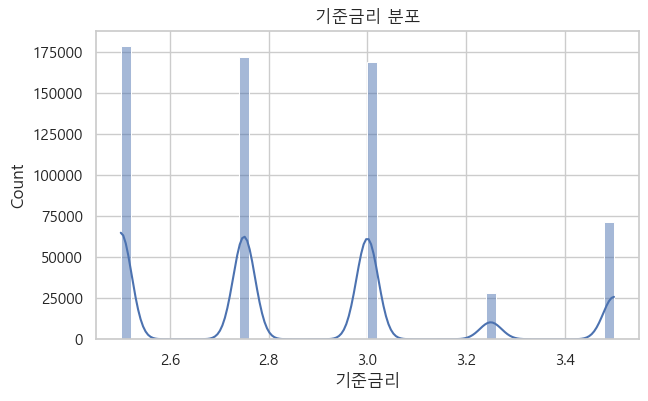

In [10]:
# 주요 숫자 변수 분포
cols_to_plot = [c for c in num_cols if c not in []]  # 필요시 제외 컬럼 넣기

for col in cols_to_plot:
    plt.figure(figsize=(7, 4))
    sns.histplot(df[col].dropna(), bins=50, kde=True)
    plt.title(f"{col} 분포")
    plt.show()


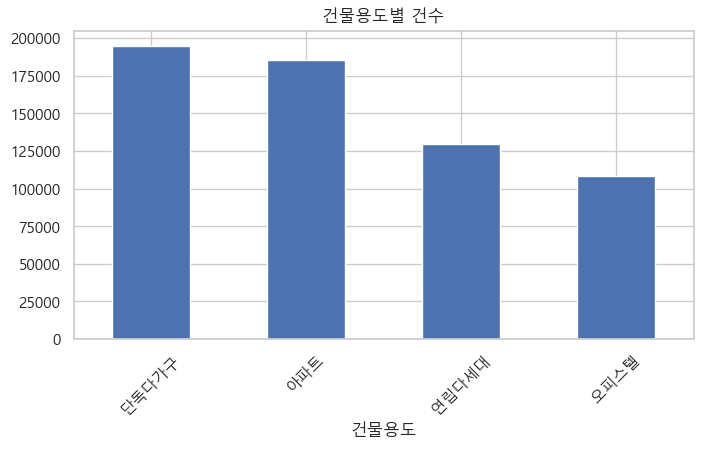

In [11]:
# 건물용도별 건수
if "건물용도" in df.columns:
    plt.figure(figsize=(8, 4))
    df["건물용도"].value_counts().plot(kind="bar")
    plt.title("건물용도별 건수")
    plt.xticks(rotation=45)
    plt.show()


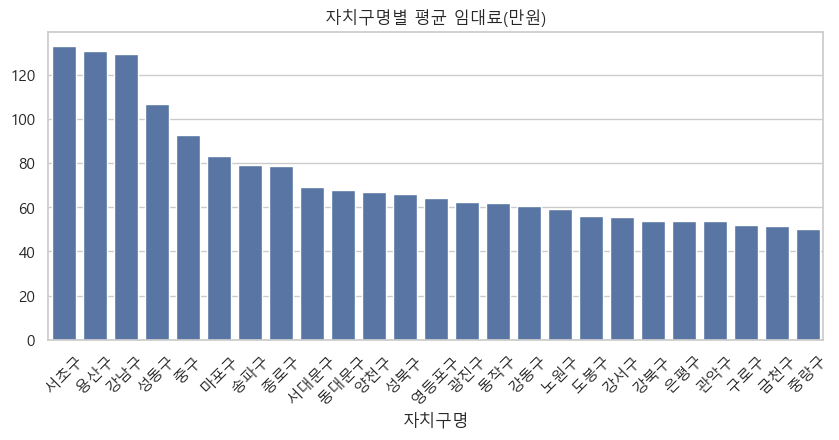

In [ ]:
# 자치구별 평균 월세/평당가 (컬럼 이름에 맞게 수정)
target_col = "임대료(만원)"
if {"자치구명", target_col}.issubset(df.columns):
    gu_mean = df.groupby("자치구명")[target_col].mean().sort_values(ascending=False)
    plt.figure(figsize=(10, 4))
    sns.barplot(x=gu_mean.index.astype(str), y=gu_mean.values)
    plt.title(f"자치구명별 평균 {target_col}")
    plt.xticks(rotation=45)
    plt.show()


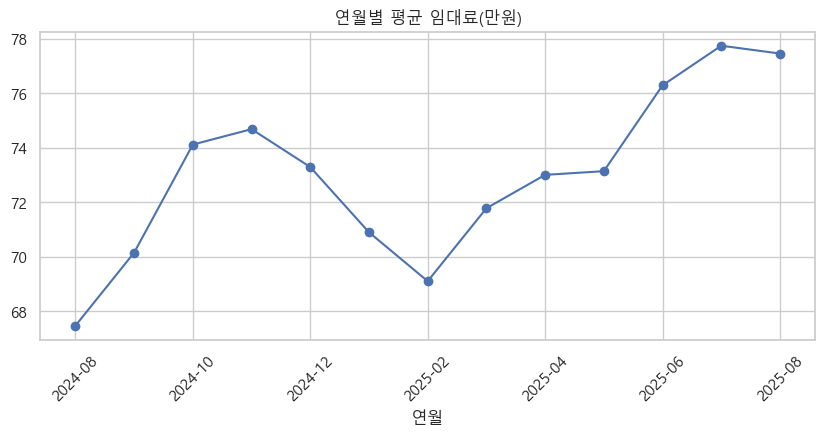

In [14]:
# 연월별 평균 월세/타깃
if {"연월", target_col}.issubset(df.columns):
    month_mean = df.groupby("연월")[target_col].mean()
    plt.figure(figsize=(10, 4))
    month_mean.plot(marker="o")
    plt.title(f"연월별 평균 {target_col}")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.show()


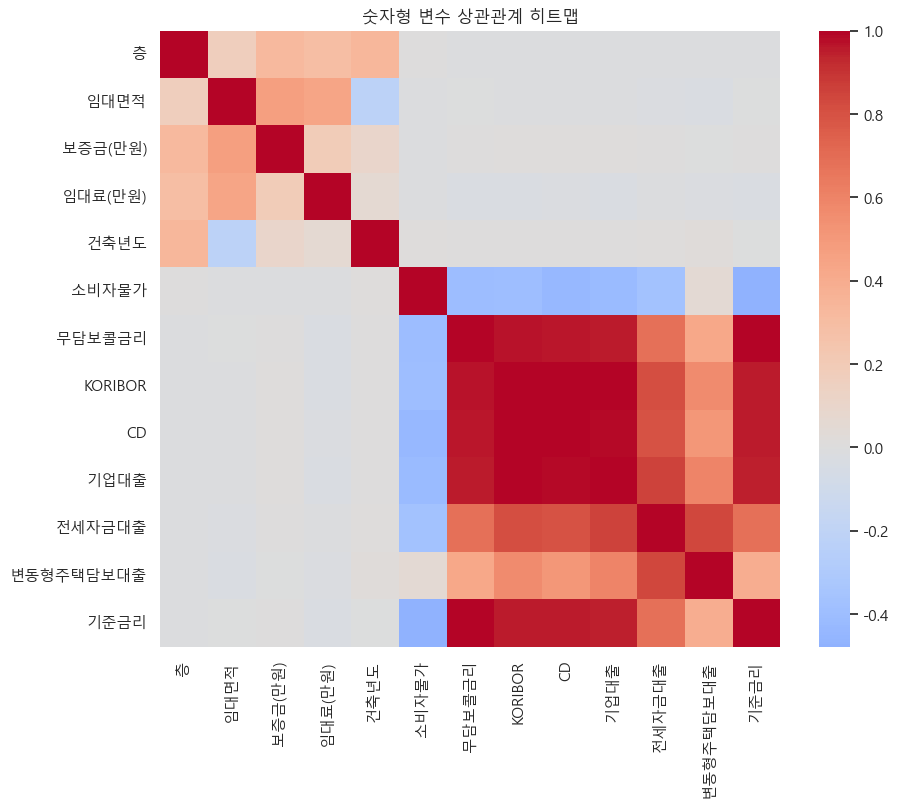

In [15]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[num_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("숫자형 변수 상관관계 히트맵")
plt.show()

In [ ]:
# 특정 타깃 기준 상관계수만 보고 싶을 때
if "임대료(만원)" in df.columns:
    target = "임대료(만원)"
else:
    target = num_cols[0]

target_corr = corr[target].sort_values(ascending=False)
target_corr


임대료(만원)      1.000000
임대면적         0.442194
층            0.290601
보증금(만원)      0.193611
건축년도         0.053524
소비자물가       -0.004731
전세자금대출      -0.014568
변동형주택담보대출   -0.017419
CD          -0.022003
기업대출        -0.023147
KORIBOR     -0.023222
기준금리        -0.025003
무담보콜금리      -0.025888
Name: 임대료(만원), dtype: float64

In [19]:
import pandas as pd

train_path = r"C:\dev\SKN18-FINAL-1TEAM\apps\reco\models\price_model\data\월세_train(24.01~25.08).csv"
test_path  = r"C:\dev\SKN18-FINAL-1TEAM\apps\reco\models\price_model\data\월세_test(25.09~25.10).csv"

train = pd.read_csv(train_path, encoding="utf-8")
test  = pd.read_csv(test_path,  encoding="utf-8")

print("=== train NaN 개수 ===")
print(train.isna().sum())

print("\n=== test NaN 개수 ===")
print(test.isna().sum())


=== train NaN 개수 ===
자치구명         0
법정동명         0
층            0
연월           0
임대면적         0
보증금(만원)      0
임대료(만원)      0
건축년도         0
건물용도         0
소비자물가        0
무담보콜금리       0
KORIBOR      0
CD           0
기업대출         0
전세자금대출       0
변동형주택담보대출    0
기준금리         0
dtype: int64

=== test NaN 개수 ===
자치구명         0
법정동명         0
층            0
연월           0
임대면적         0
보증금(만원)      0
임대료(만원)      0
건축년도         0
건물용도         0
소비자물가        0
무담보콜금리       0
KORIBOR      0
CD           0
기업대출         0
전세자금대출       0
변동형주택담보대출    0
기준금리         0
dtype: int64
